In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE

# ==========================================
# 1. Database Simulation (Relational Setup)
# ==========================================

# Table 1: Customers (id, name, main_interests)
# Let's say IDs 0-4 are tech-oriented, and 5-9 are music-oriented.
customers_df = pd.DataFrame({
    'id': list(range(10)),
    'name': [f"User_{i}" for i in range(10)],
    'main_interests': ['Tech']*5 + ['Music']*5
})

# Table 2: Customer Chats (c1, c2) - Foreign Keys to Customers table
# These records represent communications (edges) between customers.
chats_df = pd.DataFrame({
    'c1': [0, 0, 1, 1, 2, 3, 0, 5, 5, 6, 7, 8, 6, 5, 4],
    'c2': [1, 2, 2, 3, 3, 4, 4, 6, 7, 7, 8, 9, 9, 9, 5]  # (4, 5) is the cross-community bridge
})

print("Database 'customers' Table Sample:")
print(customers_df.head(3))
print("\nDatabase 'customer_chats' Table Sample:")
print(chats_df.head(3))



Database 'customers' Table Sample:
   id    name main_interests
0   0  User_0           Tech
1   1  User_1           Tech
2   2  User_2           Tech

Database 'customer_chats' Table Sample:
   c1  c2
0   0   1
1   0   2
2   1   2


In [2]:
# ==========================================
# 2. Extract Data & Build Adjacency via NetworkX
# ==========================================

# Instantiate an empty graph
G = nx.Graph()

# Efficiently convert rows to a nested dictionary keyed by 'id'
# Format: {0: {'name': 'User_0', 'main_interests': 'Tech'}, 1: ...}
node_attributes = customers_df.set_index('id').to_dict(orient='index')

# Bulk add nodes with all their respective properties
G.add_nodes_from(node_attributes.items())

# Bulk add edges directly from the underlying numpy arrays of the dataframe columns
G.add_edges_from(zip(chats_df['c1'], chats_df['c2']))

# Generate the adjacency matrix
A = nx.adjacency_matrix(G, nodelist=sorted(G.nodes())).toarray()

print("Adjacency Matrix Shape:", A.shape)
print(A)



Adjacency Matrix Shape: (10, 10)
[[0 1 1 0 1 0 0 0 0 0]
 [1 0 1 1 0 0 0 0 0 0]
 [1 1 0 1 0 0 0 0 0 0]
 [0 1 1 0 1 0 0 0 0 0]
 [1 0 0 1 0 1 0 0 0 0]
 [0 0 0 0 1 0 1 1 0 1]
 [0 0 0 0 0 1 0 1 0 1]
 [0 0 0 0 0 1 1 0 1 0]
 [0 0 0 0 0 0 0 1 0 1]
 [0 0 0 0 0 1 1 0 1 0]]


In [3]:
# ==========================================
# 3. Direct Truncated SVD (Encoder-Decoder)
# ==========================================

k = 4  # Target embedding dimension
svd = TruncatedSVD(n_components=k, random_state=42)
U_k = svd.fit_transform(A)
Sigma_k = svd.singular_values_

# Standard dot-product embedding construction: Z = U_k * sqrt(Sigma_k)
Z = U_k * np.sqrt(Sigma_k)

print(f"U shape: {U_k.shape}")
print(f"Sigma shape: {Sigma_k.shape}")
print(f"Z shape: {Z.shape}")



U shape: (10, 4)
Sigma shape: (4,)
Z shape: (10, 4)


In [ ]:
# ==========================================
# 4. Dimension Reduction via t-SNE & Plotting
# ==========================================
from adjustText import adjust_text

tsne = TSNE(n_components=2, perplexity=3, random_state=42, max_iter=1000)
Z_2d = tsne.fit_transform(Z)

plt.figure(figsize=(10, 8))

# Keep track of all individual text objects we create
texts = []

for node_id in G.nodes():
    comm = G.nodes[node_id]['main_interests']
    color = 'blue' if comm == 'Tech' else 'orange'

    # Plot the scatter points
    plt.scatter(Z_2d[node_id, 0], Z_2d[node_id, 1], c=color, s=250, zorder=3)

    # Create the text label at the exact node coordinate
    txt = plt.text(Z_2d[node_id, 0], Z_2d[node_id, 1], f"ID {node_id}\n({comm})", fontsize=9, weight='bold')
    texts.append(txt)

# Automatically repel overlapping labels from points and from each other
# arrowprops draws a thin line from the moved text back to its original node position
adjust_text(
    texts,
    arrowprops=dict(arrowstyle="->", color='gray', lw=0.5, alpha=0.7),
    expand_points=(1.5, 1.5),
    expand_text=(1.2, 1.2)
)

plt.title("SVD Representation Mapping", fontsize=13)
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

7 [-0.06805286  0.03937004]
9 [0.37818012 0.17559327]
1 [-0.13999013  0.18203793]
2 [-0.85290159  0.72394487]
0 [-0.56646116  0.63811313]
3 [-0.10148273  0.08243944]


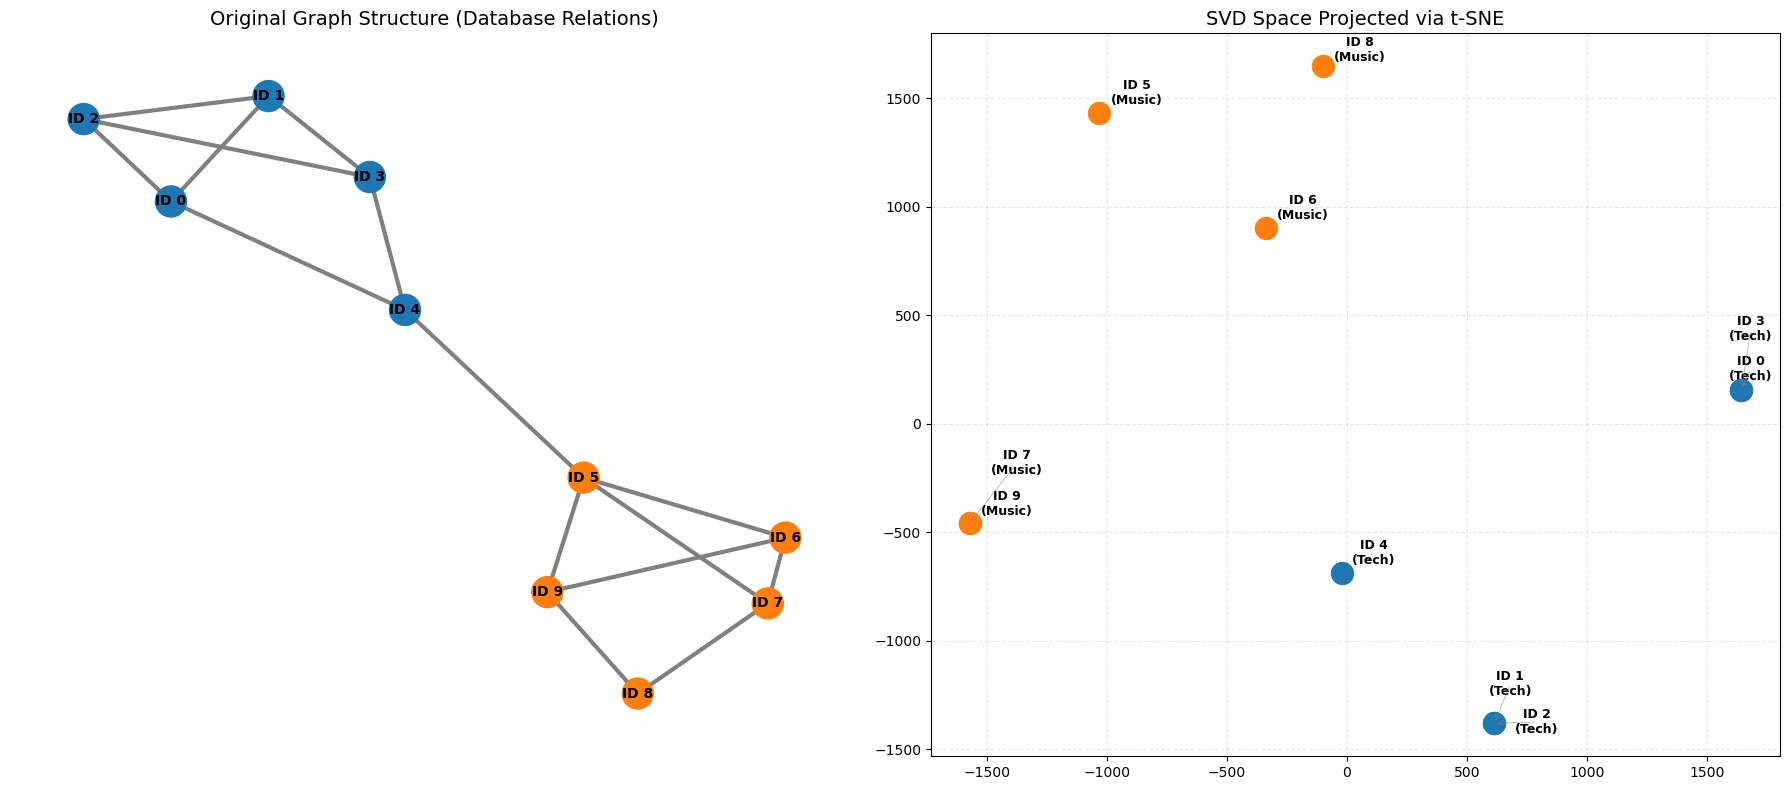

In [6]:
from adjustText import adjust_text

tsne = TSNE(n_components=2, perplexity=3, random_state=42, max_iter=1000)
Z_2d = tsne.fit_transform(Z)
# ==========================================
# 3. Side-by-Side Visualization
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Map colors based on community attribute
node_colors = ['#1f77b4' if G.nodes[n]['main_interests'] == 'Tech' else '#ff7f0e' for n in G.nodes()]

# ------------------------------------------
# Plot 1: Original Graph Topology (NetworkX)
# ------------------------------------------
# Use spring_layout to automatically space out graph nodes based on connections
pos_layout = nx.spring_layout(G, seed=42)

# Draw the backbone edges and nodes
nx.draw_networkx_edges(G, pos_layout, ax=ax1, alpha=1, edge_color='gray', width=3)
nx.draw_networkx_nodes(G, pos_layout, ax=ax1, node_color=node_colors, node_size=500)

# # Highlight bridge nodes (4 and 5) with a red border on the original graph
# nx.draw_networkx_nodes(G, pos_layout, ax=ax1, nodelist=[4, 5], node_color=node_colors[4:6],
#                        node_size=400, edgecolors='red', linewidths=2)

# Add clear labels to the topology layout
labels = {n: f"ID {n}" for n in G.nodes()}
nx.draw_networkx_labels(G, pos_layout, labels=labels, ax=ax1, font_size=10, font_weight='bold')

ax1.set_title("Original Graph Structure (Database Relations)", fontsize=14)
ax1.axis('off') # Clean up layout borders

# ------------------------------------------
# Plot 2: t-SNE Embedding Space
# ------------------------------------------
texts = []
for node_id in G.nodes():
    comm = G.nodes[node_id]['main_interests']
    color = '#1f77b4' if comm == 'Tech' else '#ff7f0e'

    ax2.scatter(Z_2d[node_id, 0], Z_2d[node_id, 1], c=color, s=250, zorder=3)

    txt = ax2.text(Z_2d[node_id, 0], Z_2d[node_id, 1], f"ID {node_id}\n({comm})", fontsize=9, weight='bold')
    texts.append(txt)

adjust_text(
    texts, ax=ax2,
    arrowprops=dict(arrowstyle="->", color='gray', lw=0.5, alpha=0.7),
    expand_points=(1.5, 1.5), expand_text=(1.2, 1.2)
)

ax2.set_title("SVD Space Projected via t-SNE", fontsize=14)
ax2.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. Database Simulation with Numeric Features
# ==========================================

# Table: Customers (id, name, main_interests, and numeric behavioral features)
# We will simulate 3 distinct behavioral archetypes:
# - IDs 0-3: "High-value loyalists" (High spend, long lifetime, low support)
# - IDs 4-6: "New/Low-engagement" (Low spend, short lifetime, low support)
# - IDs 7-9: "High-maintenance/Frustrated" (Medium spend, medium lifetime, high support)
customers_df = pd.DataFrame({
    'id': list(range(10)),
    'name': [f"User_{i}" for i in range(10)],
    'archetype': ['Loyalist']*4 + ['New']*3 + ['High-Support']*3,
    'total_spend_usd': [1200, 1450, 1100, 1300,  150,  80,  200,  500,  650,  480],
    'days_active':     [ 730,  810,  690,  750,   30,  15,   45,  200,  250,  180],
    'support_tickets': [   1,    2,    0,    1,    0,   1,    0,   12,   15,   9]
})

print("Database 'customers' Relation with Numeric Features:")
print(customers_df)

# ==========================================
# 2. Preprocessing & Feature Matrix (X)
# ==========================================

# Extract only the numeric columns to form our feature matrix X (n x m)
feature_cols = ['total_spend_usd', 'days_active', 'support_tickets']
X = customers_df[feature_cols].values
print(X)

# CRITICAL STEP: Scale features so that attributes with large ranges (like spend)
# do not completely dominate the Euclidean distance calculation in the RBF kernel.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled)


In [ ]:
from sklearn.decomposition import KernelPCA

# ==========================================
# 3. Kernel PCA (Implicit n x n RBF Proximity Matrix)
# ==========================================


# 'gamma' represents 1 / (sigma^2) in the RBF kernel formula.
computed_gamma = 1.0 / (X_scaled.shape[1] * X_scaled.var())

# Instead of calculating the n x n matrix manually and passing it to SVD,
# sklearn's KernelPCA performs the RBF transformation and eigendecomposition natively.
# 'gamma' represents 1 / (sigma^2) in the RBF kernel formula. choosing 'scale' makes it calculate the variance from the data.
k_pca = KernelPCA(n_components=k, kernel='rbf', gamma=computed_gamma, random_state=42)
Z_pca = k_pca.fit_transform(X_scaled)

print(f"\nShape of the derived embedding matrix Z: {Z_pca.shape} (n x k)")
print(Z_pca)

# ==========================================
# 4. Extracting and Visualizing the n x n Kernel Proximity Matrix
# ==========================================

# To show students what is happening under the hood, we can explicitly compute
# the explicit n x n proximity matrix P using the pairwise distances.
from sklearn.metrics.pairwise import rbf_kernel
P = rbf_kernel(X_scaled, gamma=computed_gamma)

print("\nExplicitly Computed n x n RBF Proximity Matrix (Sample 3x3):")
# print(np.round(P[:3, :3], 3))
print(np.round(P, 3))



In [ ]:
# ==========================================
# 5. Visualization with Non-Overlapping Labels
# ==========================================
tsne = TSNE(n_components=2, perplexity=3, random_state=42, max_iter=1000)
Z_2d = tsne.fit_transform(Z_pca)


plt.figure(figsize=(10, 8))

# Map colors to our behavioral archetypes
colors = {'Loyalist': '#1f77b4', 'New': '#2ca02c', 'High-Support': '#d62728'}
texts = []


for _, row in customers_df.iterrows():
    node_id = row['id']
    arch = row['archetype']

    # Plot the coordinate generated by Kernel PCA
    plt.scatter(Z_2d[node_id, 0], Z_2d[node_id, 1], c=colors[arch], s=250, zorder=3)

    # Generate label string showing ID and Archetype
    txt = plt.text(Z_2d[node_id, 0], Z_2d[node_id, 1], f"ID {node_id}\n({arch})", fontsize=9, weight='bold')
    texts.append(txt)

# Resolve overlaps smoothly
adjust_text(
    texts,
    arrowprops=dict(arrowstyle="->", color='gray', lw=0.5, alpha=0.7),
    expand_points=(1.5, 1.5), expand_text=(1.2, 1.2)
)

plt.title("Kernel PCA Embedding of Database Relation (RBF Kernel)", fontsize=13)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

In [ ]:
# Using the A adjacency matrix from the first example let's perform laplacian eignemaps

# ==========================================
# 3. Laplacian Eigenmaps (Spectral Embedding)
# ==========================================

# We instantiate SpectralEmbedding to project into a 2-dimensional space.
# By passing affinity='precomputed', we tell it that we are providing the
# raw, localized proximity matrix W directly.
from sklearn.manifold import SpectralEmbedding
laplacian_embedding = SpectralEmbedding(n_components=k, affinity='precomputed', random_state=42)
Z_laplacian = laplacian_embedding.fit_transform(A)

print("Shape of the derived Laplacian Embedding matrix Z:", Z_laplacian.shape)
print(Z_laplacian)

In [ ]:
# ==========================================
# 5. Visualization with Non-Overlapping Labels
# ==========================================
plt.figure(figsize=(10, 8))

texts = []
for node_id in G.nodes():
    comm = G.nodes[node_id]['main_interests']
    color = '#1f77b4' if comm == 'Tech' else '#ff7f0e'

    # Plot the coordinate generated by Laplacian Eigenmaps
    plt.scatter(Z_2d[node_id, 0], Z_2d[node_id, 1], c=color, s=250, zorder=3)


    txt = plt.text(Z_2d[node_id, 0], Z_2d[node_id, 1], f"ID {node_id}\n({comm})", fontsize=9, weight='bold')
    texts.append(txt)

# Adjust label placements to completely resolve text overlaps
adjust_text(
    texts,
    arrowprops=dict(arrowstyle="->", color='gray', lw=0.5, alpha=0.7),
    expand_points=(1.5, 1.5), expand_text=(1.2, 1.2)
)

plt.title("Laplacian Eigenmaps Node Embedding (Manifold Learning via L = D - A)", fontsize=13)
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()